# Build HNSW Index

Loads synthetic deal data, engineers features, builds HNSW nearest neighbor index.
Saves index artifacts to `backend/data/models/hnsw/`.

Based on: Cooper & Busch (2026), *Capacity-Limited Failure in Approximate
Nearest Neighbor Search on Image Embedding Spaces*, J. Imaging 12(2), 55.

In [1]:
import json
import glob
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../backend/src')
from nodes.feature_engineer import engineer_features
from nodes.nn_retrieval import (
    build_index, load_index, query_neighbors,
    compute_nn_churn_rate, features_to_vector, FEATURE_COLUMNS
)

sns.set_style('whitegrid')

## Load & Feature Engineer All Deals

In [2]:
deal_files = sorted(glob.glob('../backend/data/synthetic/DEAL-*.json'))
print(f'Found {len(deal_files)} deals')

deals = []
features_list = []
metadata_list = []

for f_path in deal_files:
    with open(f_path) as f:
        deal = json.load(f)
    deals.append(deal)
    
    feat = engineer_features(deal)
    features_list.append(feat)
    
    # Metadata stored alongside each vector in the index
    metadata_list.append({
        'deal_id': deal['deal_id'],
        'company_name': deal['company']['name'],
        'segment': deal['company']['segment'],
        'industry': deal['company']['industry'],
        'amount': deal['deal']['amount'],
        'outcome': deal['outcome']['status'],
        'days_to_churn': deal['outcome'].get('days_to_churn'),
        'churn_reason': deal['outcome'].get('churn_reason'),
    })

print(f'Engineered features for {len(features_list)} deals')
print(f'Feature vector dimension: {len(FEATURE_COLUMNS)}')

Found 805 deals
Engineered features for 805 deals
Feature vector dimension: 54


## Build Index

In [3]:
# Build HNSW index with M=32, ef_construction=200
build_index(features_list, metadata_list, m=32, ef_construction=200)

HNSW index built: 805 vectors, 54 dimensions
Saved to /Users/morgancooper/GTM-AskElephant/notebooks/../backend/src/nodes/../../data/models/hnsw/


## Test Retrieval

In [4]:
# Load the index
load_index()

# Query with first deal — should find itself + similar deals
test_features = features_list[0]
neighbors = query_neighbors(test_features, k=5, alpha=4.0)

print(f"Query deal: {test_features['deal_id']}")
print(f"NN churn rate: {compute_nn_churn_rate(neighbors):.0%}")
print(f"\nNearest neighbors:")
for i, n in enumerate(neighbors):
    print(f"  {i+1}. {n['deal_id']} ({n['company_name']}) | "
          f"{n['segment']} | ${n['amount']:,.0f} | "
          f"outcome: {n['outcome']} | dist: {n['distance']:.3f}")

HNSW index loaded: 805 vectors, 54 dimensions
Query deal: DEAL-0001
NN churn rate: 20%

Nearest neighbors:
  1. DEAL-0001 (NovaAnalytics) | smb | $3,100 | outcome: retained | dist: 0.000
  2. DEAL-0699 (QuartzExchange) | smb | $7,900 | outcome: retained | dist: 49.783
  3. DEAL-0689 (IonData) | smb | $4,800 | outcome: expanded | dist: 51.285
  4. DEAL-0771 (ClearDigital) | smb | $4,000 | outcome: churned | dist: 57.529
  5. DEAL-0541 (StellarHub) | mid_market | $13,200 | outcome: retained | dist: 58.812


In [14]:
# Test with a few more deals — check diversity of neighbors
print(f"{'Query':>12} | {'Seg':>11} | {'Amt':>8} | {'NN Churn':>8} | {'Neighbors':>50}")
print('-' * 100)

for feat in features_list[:10]:
    neighbors = query_neighbors(feat, k=5, alpha=4.0)
    nn_churn = compute_nn_churn_rate(neighbors)
    nn_ids = ', '.join(f"{n['deal_id']}({n['outcome'][0]})" for n in neighbors)
    
    deal = next(d for d in deals if d['deal_id'] == feat['deal_id'])
    print(f"{feat['deal_id']:>12} | {deal['company']['segment']:>11} | "
          f"${feat['amount']:>7,.0f} | {nn_churn:>7.0%} | {nn_ids}")

       Query |         Seg |      Amt | NN Churn |                                          Neighbors
----------------------------------------------------------------------------------------------------
   DEAL-0001 |         smb | $  3,100 |     20% | DEAL-0001(r), DEAL-0699(r), DEAL-0689(e), DEAL-0771(c), DEAL-0541(r)
   DEAL-0002 |  mid_market | $ 18,500 |     20% | DEAL-0002(c), DEAL-0438(r), DEAL-0651(r), DEAL-0801(r), DEAL-0574(r)
   DEAL-0003 |         smb | $  3,800 |      0% | DEAL-0003(r), DEAL-0466(r), DEAL-0492(r), DEAL-0499(r), DEAL-0132(r)
   DEAL-0004 |         smb | $  3,800 |     20% | DEAL-0004(r), DEAL-0513(c), DEAL-0700(r), DEAL-0732(r), DEAL-0147(r)
   DEAL-0005 |         smb | $  4,100 |     20% | DEAL-0005(r), DEAL-0214(c), DEAL-0784(e), DEAL-0499(r), DEAL-0069(e)
   DEAL-0006 |         smb | $  7,300 |     20% | DEAL-0006(c), DEAL-0673(r), DEAL-0632(r), DEAL-0544(r), DEAL-0711(e)
   DEAL-0007 |         smb | $  6,500 |      0% | DEAL-0007(r), DEAL-0775(e), DEAL-

## Validate: Do Similar Deals Have Similar Outcomes?

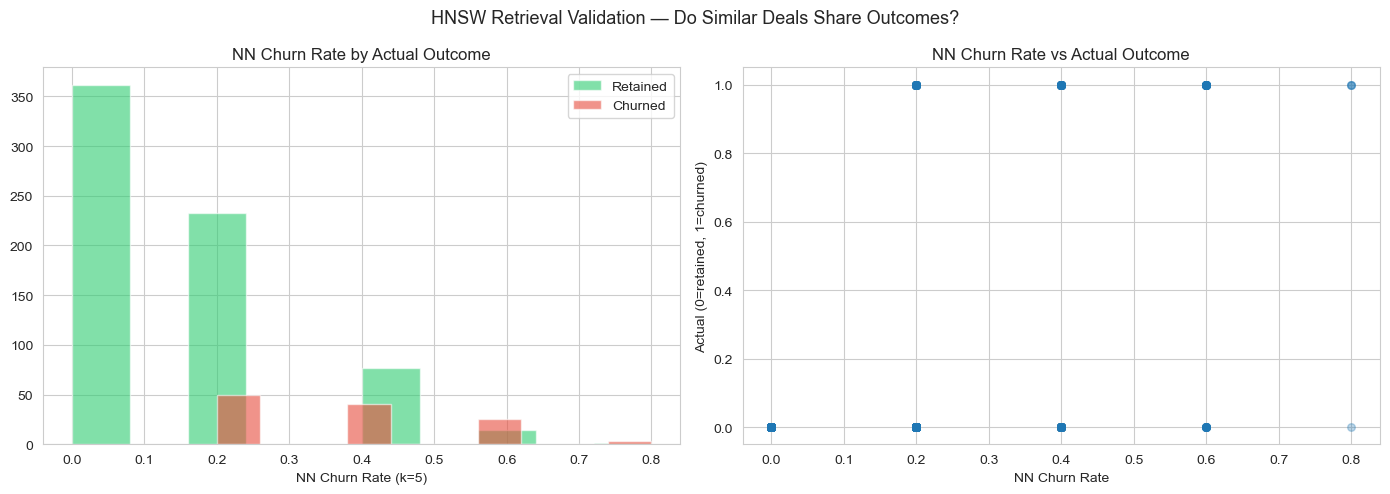


Correlation between NN churn rate and actual outcome: 0.481


In [6]:
# For each deal, get NN churn rate and compare to actual outcome
nn_churn_rates = []
actual_outcomes = []

for feat, deal in zip(features_list, deals):
    neighbors = query_neighbors(feat, k=5, alpha=4.0)
    nn_churn = compute_nn_churn_rate(neighbors)
    nn_churn_rates.append(nn_churn)
    actual_outcomes.append(1 if deal['outcome']['status'] == 'churned' else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NN churn rate distribution by actual outcome
retained_nn = [r for r, a in zip(nn_churn_rates, actual_outcomes) if a == 0]
churned_nn = [r for r, a in zip(nn_churn_rates, actual_outcomes) if a == 1]

axes[0].hist(retained_nn, bins=10, alpha=0.6, color='#2ecc71', label='Retained')
axes[0].hist(churned_nn, bins=10, alpha=0.6, color='#e74c3c', label='Churned')
axes[0].set_title('NN Churn Rate by Actual Outcome')
axes[0].set_xlabel('NN Churn Rate (k=5)')
axes[0].legend()

# Scatter: NN churn rate vs actual outcome
axes[1].scatter(nn_churn_rates, actual_outcomes, alpha=0.3, s=30)
axes[1].set_title('NN Churn Rate vs Actual Outcome')
axes[1].set_xlabel('NN Churn Rate')
axes[1].set_ylabel('Actual (0=retained, 1=churned)')

plt.suptitle('HNSW Retrieval Validation — Do Similar Deals Share Outcomes?', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nCorrelation between NN churn rate and actual outcome: "
      f"{np.corrcoef(nn_churn_rates, actual_outcomes)[0,1]:.3f}")

## t-SNE Visualization of Deal Embeddings

Project the 54-dimensional deal embeddings to 2D to see how similar deals cluster.
Color by outcome to check if churned deals cluster together in the embedding space.

In [7]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Build the same normalized matrix we used for HNSW
vectors = np.array([features_to_vector(f) for f in features_list])
scaler = StandardScaler()
vectors_scaled = scaler.fit_transform(vectors)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42, init='pca')
embeddings_2d = tsne.fit_transform(vectors_scaled)

print(f't-SNE output shape: {embeddings_2d.shape}')


t-SNE output shape: (805, 2)


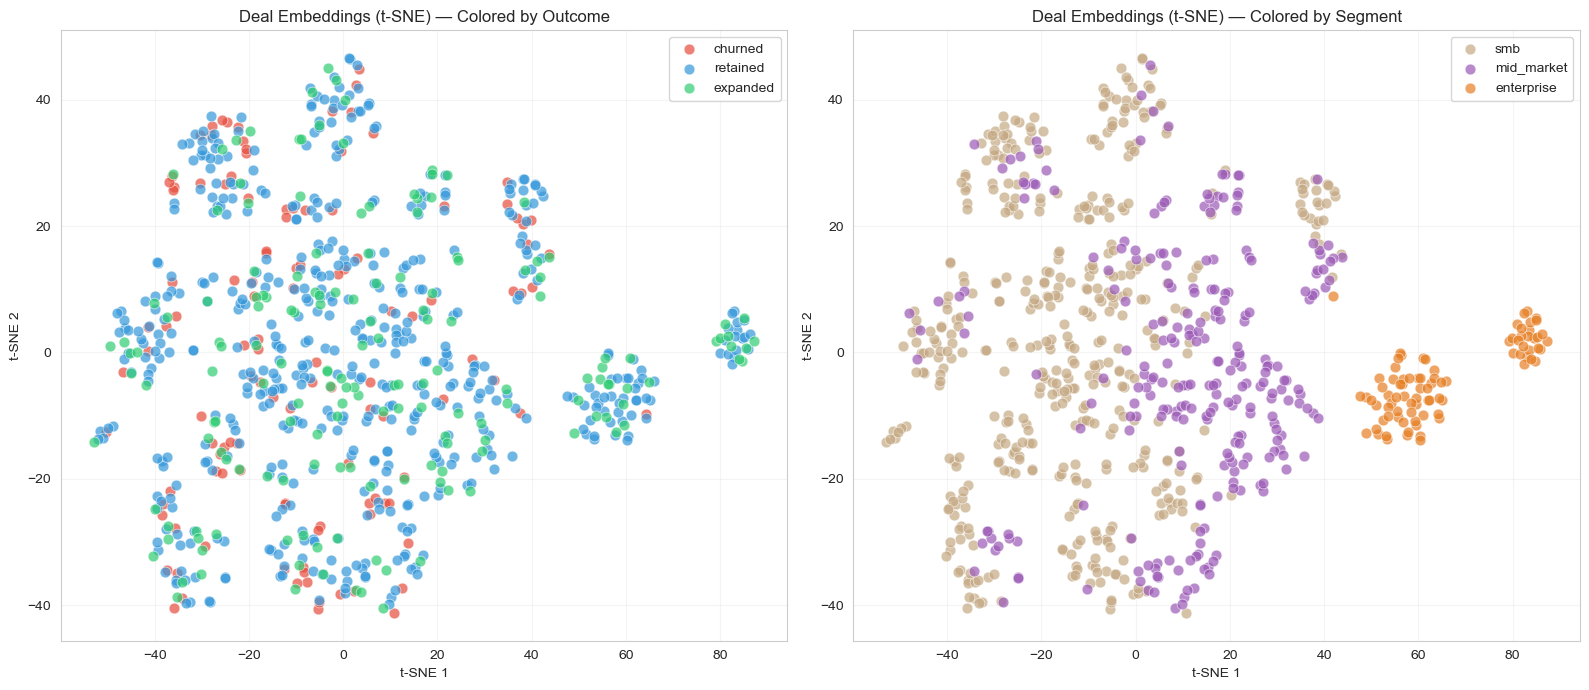

In [8]:
# Color by outcome
outcomes = [d['outcome']['status'] for d in deals]
segments = [d['company']['segment'] for d in deals]

outcome_colors = {'churned': '#e74c3c', 'retained': '#3498db', 'expanded': '#2ecc71'}
segment_colors = {'smb': '#C4A882', 'mid_market': '#9b59b6', 'enterprise': '#e67e22'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: color by outcome
for outcome, color in outcome_colors.items():
    mask = [o == outcome for o in outcomes]
    points = embeddings_2d[mask]
    if len(points) > 0:
        axes[0].scatter(points[:, 0], points[:, 1], c=color, label=outcome,
                        s=60, alpha=0.7, edgecolors='white', linewidths=0.5)
axes[0].set_title('Deal Embeddings (t-SNE) — Colored by Outcome')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Right: color by segment
for segment, color in segment_colors.items():
    mask = [s == segment for s in segments]
    points = embeddings_2d[mask]
    if len(points) > 0:
        axes[1].scatter(points[:, 0], points[:, 1], c=color, label=segment,
                        s=60, alpha=0.7, edgecolors='white', linewidths=0.5)
axes[1].set_title('Deal Embeddings (t-SNE) — Colored by Segment')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


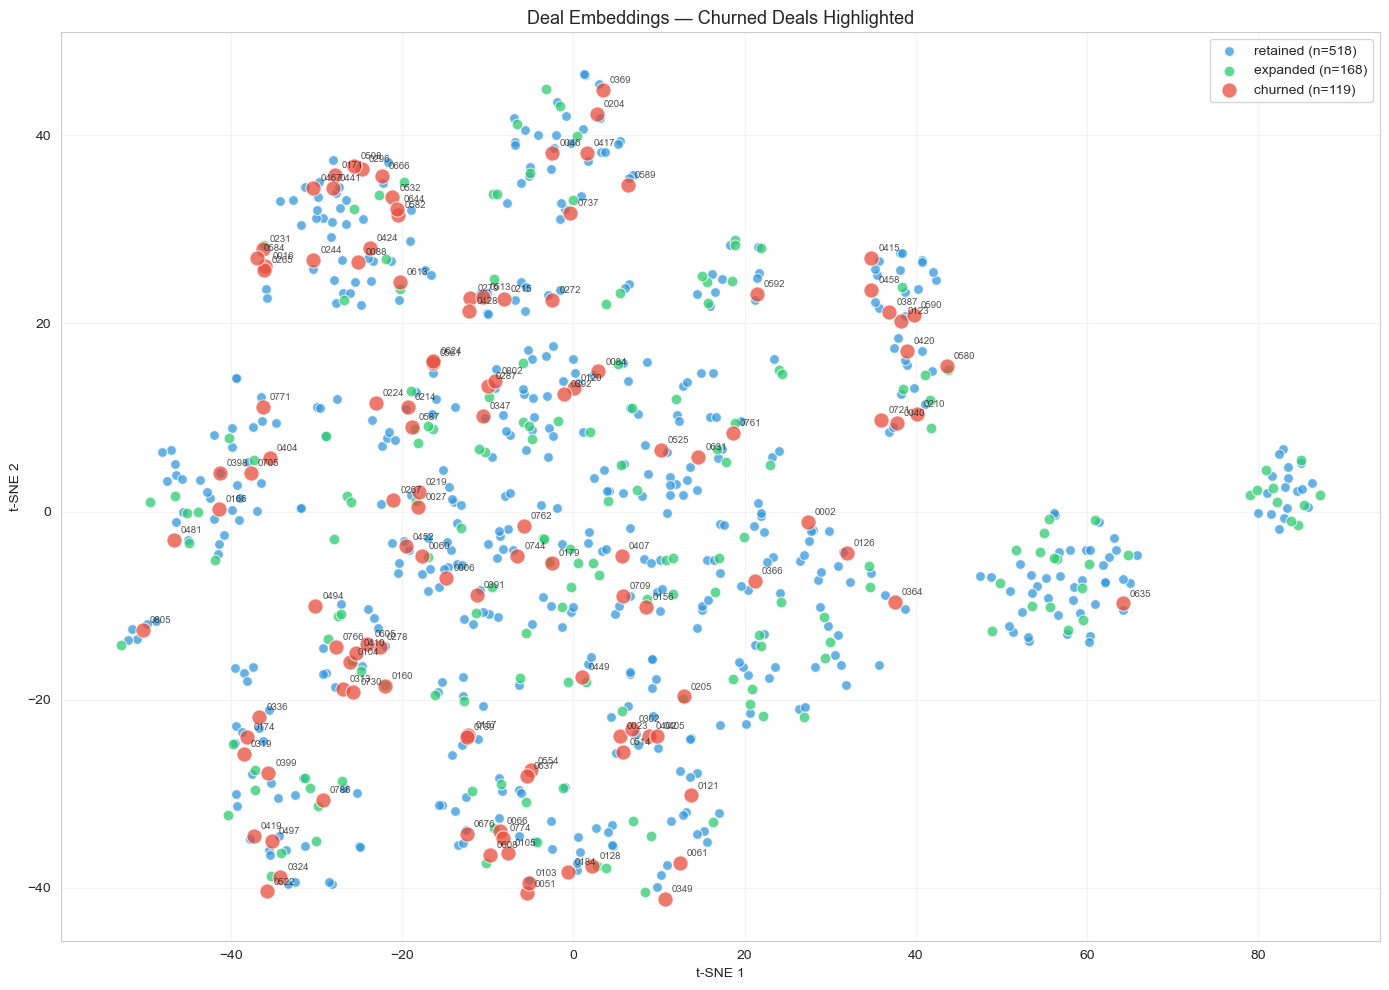

In [9]:
# Annotated version — label churned deals to see where they sit
fig, ax = plt.subplots(figsize=(14, 10))

for outcome, color, size in [('retained', '#3498db', 50), ('expanded', '#2ecc71', 60), ('churned', '#e74c3c', 120)]:
    mask = [o == outcome for o in outcomes]
    points = embeddings_2d[mask]
    if len(points) > 0:
        ax.scatter(points[:, 0], points[:, 1], c=color, label=f'{outcome} (n={sum(mask)})',
                   s=size, alpha=0.75, edgecolors='white', linewidths=0.8, zorder=3 if outcome=='churned' else 2)

# Annotate churned deals
for i, d in enumerate(deals):
    if d['outcome']['status'] == 'churned':
        ax.annotate(d['deal_id'].replace('DEAL-', ''), embeddings_2d[i],
                    fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')

ax.set_title('Deal Embeddings — Churned Deals Highlighted', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(loc='best')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## PCA Visualization

PCA preserves global distance structure (what HNSW actually uses for retrieval).
t-SNE distorts distances in favor of local neighborhoods — both views together tell the full story.

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(vectors_scaled)

print(f'PCA output shape: {embeddings_pca.shape}')
print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')
print(f'Total 2D variance captured: {sum(pca.explained_variance_ratio_):.1%}')


PCA output shape: (805, 2)
Variance explained: PC1=22.1%, PC2=7.9%
Total 2D variance captured: 30.0%


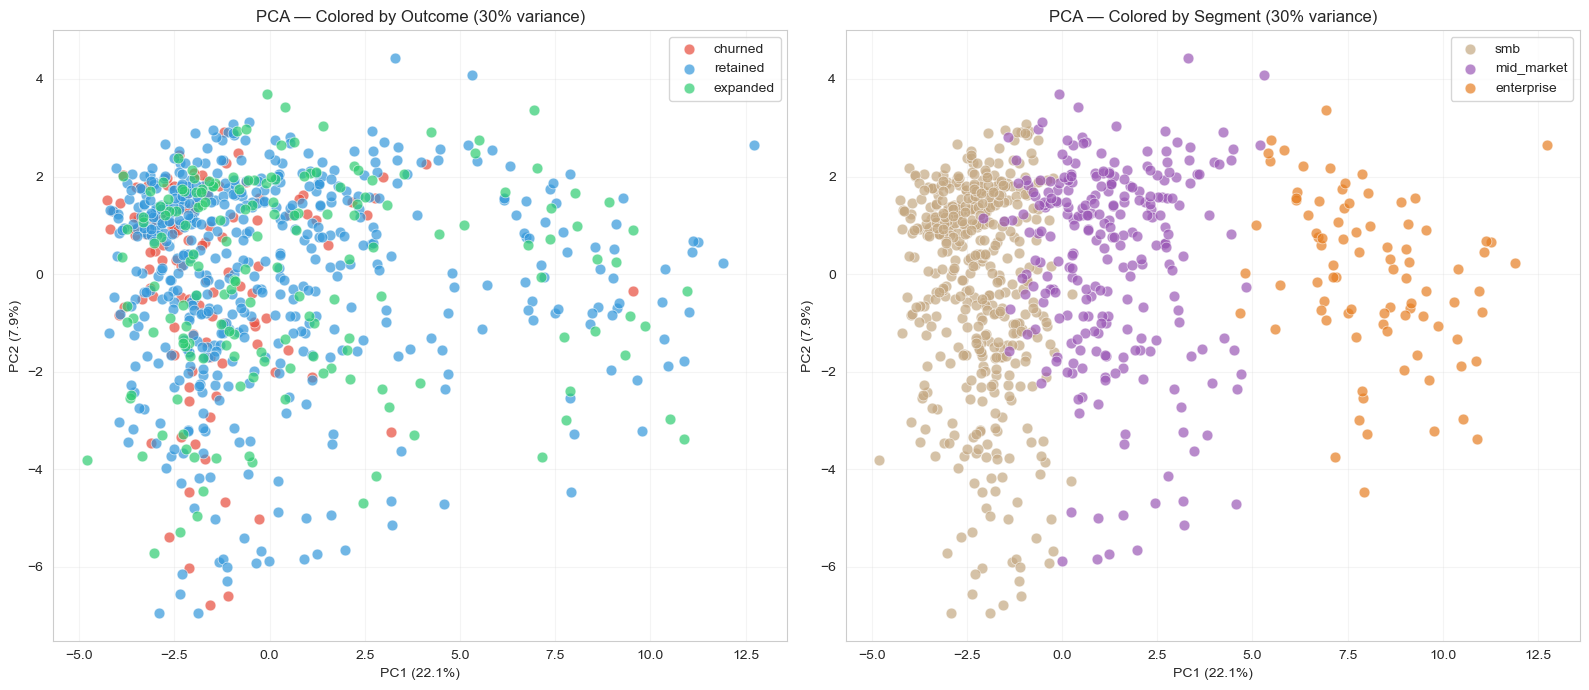

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: by outcome
for outcome, color in outcome_colors.items():
    mask = [o == outcome for o in outcomes]
    points = embeddings_pca[mask]
    if len(points) > 0:
        axes[0].scatter(points[:, 0], points[:, 1], c=color, label=outcome,
                        s=60, alpha=0.7, edgecolors='white', linewidths=0.5)
axes[0].set_title(f'PCA — Colored by Outcome ({sum(pca.explained_variance_ratio_):.0%} variance)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Right: by segment
for segment, color in segment_colors.items():
    mask = [s == segment for s in segments]
    points = embeddings_pca[mask]
    if len(points) > 0:
        axes[1].scatter(points[:, 0], points[:, 1], c=color, label=segment,
                        s=60, alpha=0.7, edgecolors='white', linewidths=0.5)
axes[1].set_title(f'PCA — Colored by Segment ({sum(pca.explained_variance_ratio_):.0%} variance)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


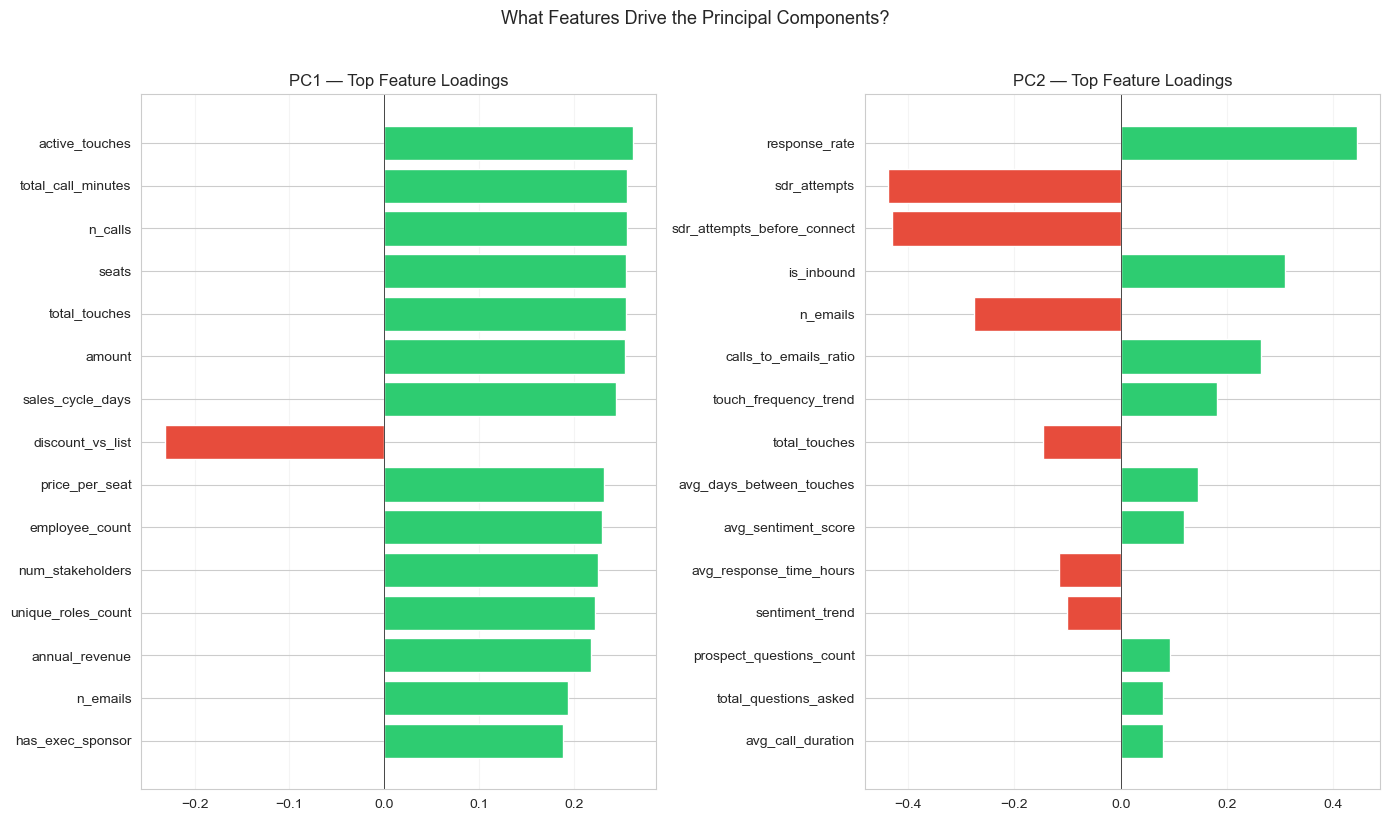

In [12]:
# What features drive PC1 and PC2?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=FEATURE_COLUMNS
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# PC1 — sort by absolute loading
pc1_top = loadings['PC1'].reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head(15)
colors_pc1 = ['#e74c3c' if v < 0 else '#2ecc71' for v in pc1_top.values]
axes[0].barh(pc1_top.index[::-1], pc1_top.values[::-1], color=colors_pc1[::-1])
axes[0].set_title('PC1 — Top Feature Loadings')
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.2, axis='x')

# PC2
pc2_top = loadings['PC2'].reindex(loadings['PC2'].abs().sort_values(ascending=False).index).head(15)
colors_pc2 = ['#e74c3c' if v < 0 else '#2ecc71' for v in pc2_top.values]
axes[1].barh(pc2_top.index[::-1], pc2_top.values[::-1], color=colors_pc2[::-1])
axes[1].set_title('PC2 — Top Feature Loadings')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.2, axis='x')

plt.suptitle('What Features Drive the Principal Components?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Components for 80% variance: 22
Components for 95% variance: 32
Full dimension: 54


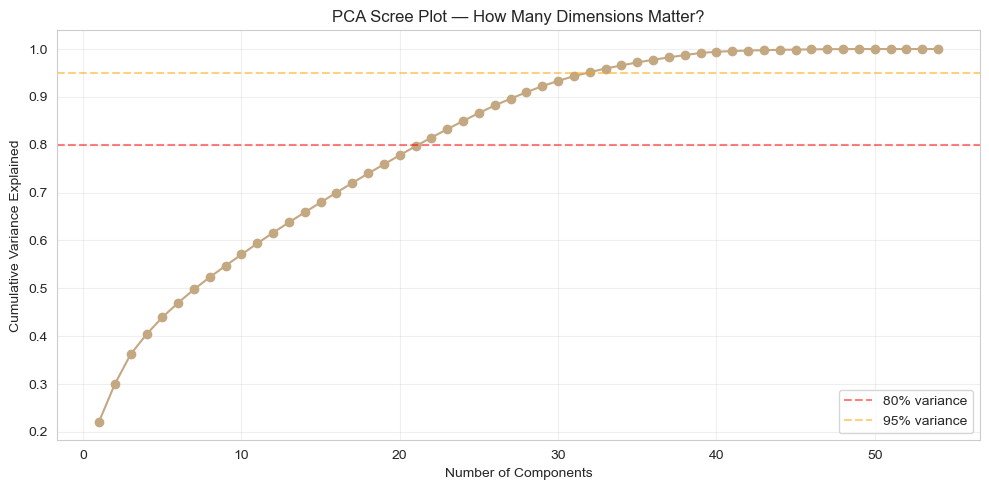

In [13]:
# Scree plot — how many PCs to capture most variance?
pca_full = PCA(random_state=42)
pca_full.fit(vectors_scaled)

fig, ax = plt.subplots(figsize=(10, 5))
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o', color='#C4A882')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='80% variance')
ax.axhline(0.95, color='orange', linestyle='--', alpha=0.5, label='95% variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('PCA Scree Plot — How Many Dimensions Matter?')
ax.legend()
ax.grid(True, alpha=0.3)

# Find k for 80% and 95%
k80 = np.argmax(cumulative >= 0.8) + 1
k95 = np.argmax(cumulative >= 0.95) + 1
print(f'Components for 80% variance: {k80}')
print(f'Components for 95% variance: {k95}')
print(f'Full dimension: {len(FEATURE_COLUMNS)}')

plt.tight_layout()
plt.show()
